In [1]:
import pandas as pd

In [2]:
dataUSD = pd.read_excel('tcmb_usd_verisi_1000.xlsx')
df = dataUSD.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1238 non-null   object 
 1   Yıl            1238 non-null   int64  
 2   Ay             1238 non-null   int64  
 3   Alış (Forex)   1238 non-null   float64
 4   Satış (Forex)  1238 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 48.5+ KB


In [5]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex)
0,2020-12-07,2020,12,7.8373,7.8514
1,2020-12-08,2020,12,7.8087,7.8227
2,2020-12-09,2020,12,7.8203,7.8344
3,2020-12-10,2020,12,7.8499,7.8640
4,2020-12-11,2020,12,7.9349,7.9492


In [7]:
df['Gun'] = df['Tarih'].apply(lambda x: int(x[-2:]))

In [9]:
df.Gun

0        7
1        8
2        9
3       10
4       11
        ..
1233     1
1234     2
1235     3
1236     4
1237     5
Name: Gun, Length: 1238, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tarih          1238 non-null   object 
 1   Yıl            1238 non-null   int64  
 2   Ay             1238 non-null   int64  
 3   Alış (Forex)   1238 non-null   float64
 4   Satış (Forex)  1238 non-null   float64
 5   Gun            1238 non-null   int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 58.2+ KB


In [15]:
print(df.sample(15))

           Tarih   Yıl  Ay  Alış (Forex)  Satış (Forex)  Gun
416   2022-08-16  2022   8       17.9420        17.9744   16
99    2021-04-29  2021   4        8.1753         8.1900   29
1237  2025-12-05  2025  12       42.3606        42.4369    5
900   2024-07-29  2024   7       32.9509        33.0102   29
1089  2025-04-30  2025   4       38.3684        38.4375   30
438   2022-09-16  2022   9       18.2474        18.2802   16
442   2022-09-22  2022   9       18.3401        18.3732   22
1007  2024-12-31  2024  12       35.2803        35.3438   31
516   2023-01-05  2023   1       18.7387        18.7725    5
688   2023-09-18  2023   9       26.9814        27.0300   18
1134  2025-07-09  2025   7       39.9621        40.0341    9
1194  2025-10-03  2025  10       41.5226        41.5974    3
512   2022-12-30  2022  12       18.6983        18.7320   30
799   2024-02-22  2024   2       30.9582        31.0140   22
529   2023-01-25  2023   1       18.7850        18.8188   25


In [17]:
df['Tarih'] = pd.to_datetime(df['Tarih'])
df = df.sort_values(by = 'Tarih')
df = df.reset_index(drop=True)

In [19]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun
0,2020-12-07,2020,12,7.8373,7.8514,7
1,2020-12-08,2020,12,7.8087,7.8227,8
2,2020-12-09,2020,12,7.8203,7.8344,9
3,2020-12-10,2020,12,7.8499,7.8640,10
4,2020-12-11,2020,12,7.9349,7.9492,11


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Tarih          1238 non-null   datetime64[ns]
 1   Yıl            1238 non-null   int64         
 2   Ay             1238 non-null   int64         
 3   Alış (Forex)   1238 non-null   float64       
 4   Satış (Forex)  1238 non-null   float64       
 5   Gun            1238 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 58.2 KB


In [23]:
df['Haftalik_Ortalama'] = df['Alış (Forex)'].rolling(window=7).mean()

In [27]:
df.isna().sum()

Tarih                0
Yıl                  0
Ay                   0
Alış (Forex)         0
Satış (Forex)        0
Gun                  0
Haftalik_Ortalama    6
dtype: int64

In [29]:
df['Onceki_Gun_Fiyat'] = df['Alış (Forex)'].shift(1)

In [31]:
df.dropna(inplace=True)

In [33]:
df.reset_index(drop=True, inplace=True)

In [35]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,7.8331,7.8473,15,7.850586,7.8699
1,2020-12-16,2020,12,7.7873,7.8013,16,7.843443,7.8331
2,2020-12-17,2020,12,7.7510,7.7650,17,7.835200,7.7873
3,2020-12-18,2020,12,7.6898,7.7036,18,7.816557,7.7510
4,2020-12-21,2020,12,7.6769,7.6907,21,7.791843,7.6898


In [39]:
df.isna().sum().sum()

0

In [41]:
X = df[['Yıl', 'Ay', 'Gun', 'Onceki_Gun_Fiyat', 'Haftalik_Ortalama']]
y = df['Alış (Forex)']

In [45]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [49]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [51]:
model_configs = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {} # Linear Regression'da genelde hiperparametre aranmaz
    },
    'Ridge': {
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0] # Ceza katsayısı
        }
    },
    'Lasso': {
        'model': Lasso(),
        'params': {
            'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0] # Ceza katsayısı
        }
    }
}

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [69]:
tscv = TimeSeriesSplit(n_splits=5)

results = []

print("Modeller eğitiliyor ve GridSearch yapılıyor...\n")

for model_name, config in model_configs.items():
    # Pipeline Kurulumu
    pipe = Pipeline([
        ('scaler', StandardScaler()),     # Veriyi standardize et
        ('regressor', config['model'])    # Modeli koy
    ])
    
    # GridSearch Kurulumu
    grid = GridSearchCV(
        estimator=pipe, 
        param_grid=config['params'], 
        cv=tscv,                          # Zaman serisi uyumlu CV
        scoring='neg_mean_squared_error', # Hata metriği (MSE)
        n_jobs=-1                         # Tüm işlemcileri kullan
    )
    
    # Eğit
    grid.fit(X_train, y_train)
    
    # En iyi modeli al ve test et
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Test Seti RMSE: {rmse:.4f}")
    print(f"Test Seti R2 Score: {r2:.4f}\n")
    
    results.append({
        'Model': model_name,
        'Best_Model_Object': best_model,
        'RMSE': rmse,
        'R2': r2
    })

# Sonuçları karşılaştırma (En düşük RMSE en iyisidir)
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("KAZANAN MODEL:")
print(results_df.iloc[0])

Modeller eğitiliyor ve GridSearch yapılıyor...

--- LinearRegression ---
En İyi Parametreler: {}
Test Seti RMSE: 0.0970
Test Seti R2 Score: 0.9984

--- Ridge ---
En İyi Parametreler: {'regressor__alpha': 0.01}
Test Seti RMSE: 0.0968
Test Seti R2 Score: 0.9984

--- Lasso ---
En İyi Parametreler: {'regressor__alpha': 0.001}
Test Seti RMSE: 0.0982
Test Seti R2 Score: 0.9984

KAZANAN MODEL:
Model                                                Ridge
Best_Model_Object    (StandardScaler(), Ridge(alpha=0.01))
RMSE                                              0.096812
R2                                                0.998397
Name: 1, dtype: object


In [77]:
final_best_model = results_df.iloc[0]['Best_Model_Object']

In [79]:
import joblib

# Kazanan modeli (final_best_model değişkenindeydi) kaydediyoruz
# Dosya adını projenle uyumlu verebilirsin
filename = 'USD_Model.pkl'

joblib.dump(final_best_model, filename)

print(f"Model başarıyla '{filename}' olarak kaydedildi!")

Model başarıyla 'USD_Model.pkl' olarak kaydedildi!


In [83]:
df.head()

,Tarih,Yıl,Ay,Alış (Forex),Satış (Forex),Gun,Haftalik_Ortalama,Onceki_Gun_Fiyat
0,2020-12-15,2020,12,7.8331,7.8473,15,7.850586,7.8699
1,2020-12-16,2020,12,7.7873,7.8013,16,7.843443,7.8331
2,2020-12-17,2020,12,7.7510,7.7650,17,7.835200,7.7873
3,2020-12-18,2020,12,7.6898,7.7036,18,7.816557,7.7510
4,2020-12-21,2020,12,7.6769,7.6907,21,7.791843,7.6898


In [85]:
df.to_csv('dolar_fit_veri.csv')

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

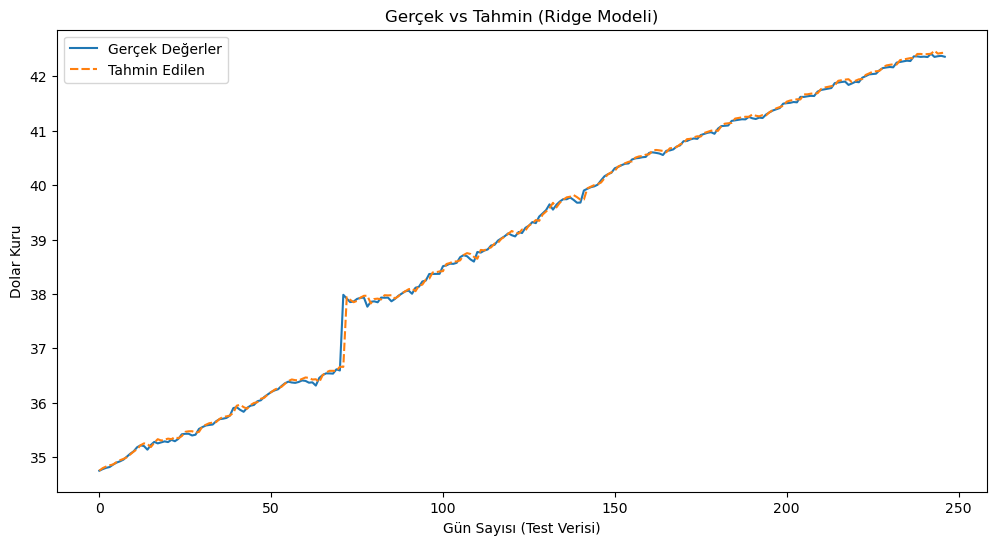

In [105]:
# 1. Tahminleri alalım
tahminler = final_best_model.predict(X_test)

# 2. Karşılaştırma DataFrame'i oluşturalım
# y_test.values diyerek indeksi çöpe atıyoruz, sadece rakamları alıyoruz.
karsilastirma = pd.DataFrame({
    'Gerçek Değerler': y_test.values,
    'Tahmin Edilen': tahminler
})

# 3. Çizdirelim
plt.figure(figsize=(12, 6))
sns.lineplot(data=karsilastirma)
plt.title('Gerçek vs Tahmin (Ridge Modeli)')
plt.ylabel('Dolar Kuru')
plt.xlabel('Gün Sayısı (Test Verisi)')
plt.show()